**Детекция токсичных комментариев**

Мульти-лейбл классификация комментариев по 6 меткам токсичности: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`.

Датасет: [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge) (Kaggle).

**План работы:**
1. EDA и предобработка
2. Feature engineering
3. Классические ML-модели (Logistic Regression, Random Forest, Gradient Boosting) + подбор гиперпараметров + кросс-валидация
4. Порог классификации для каждого лейбла, Precision-Recall tradeoff
5. Нейронная сеть MLP (Keras) с регуляризацией
6. Сравнение моделей и выводы
7. Бонус: feature importance / SHAP


In [41]:
import os
import re
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, precision_recall_curve,
    precision_score, recall_score, classification_report
)

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    from sklearn.ensemble import GradientBoostingClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
print("LightGBM available:", HAS_LGBM)


LightGBM available: True


In [13]:
train = pd.read_csv('/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv')


print("Размер train:", train.shape)
train.head()


Размер train: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## EDA и предобработка

### Описание датасета: размер, типы признаков, целевая переменная

In [14]:
print("Строк:", train.shape[0], " Столбцов:", train.shape[1])
print()
print(train.dtypes)
print()
print("Целевая переменная — 6 бинарных лейблов (мульти-лейбл задача):")
print(LABELS)
print("Пропуски по столбцам:")
print(train.isna().sum())

Строк: 159571  Столбцов: 8

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

Целевая переменная — 6 бинарных лейблов (мульти-лейбл задача):
['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Пропуски по столбцам:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Признак - сырой текст комментария. Остальные 6 столбцов - бинарные метки токсичности, не взаимоисключают друг друга.

### Визуализация распределений: баланс классов

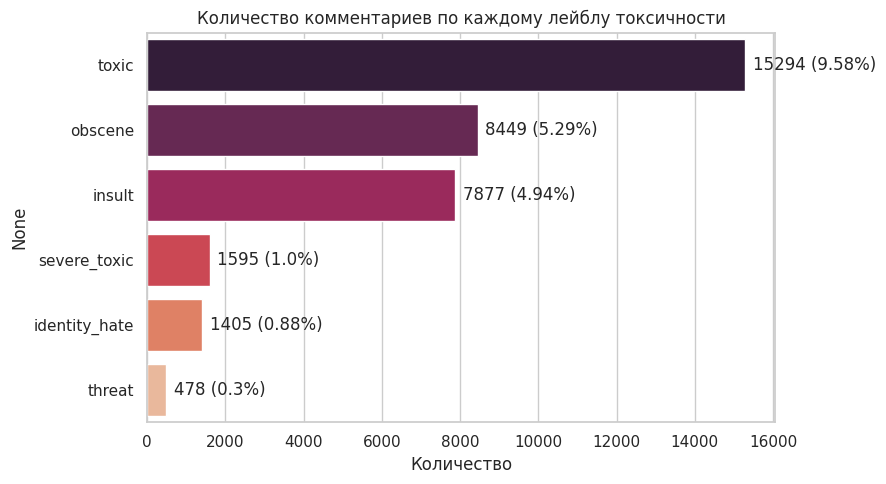

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [15]:
label_counts = train[LABELS].sum().sort_values(ascending=False)
label_share = (label_counts / len(train) * 100).round(2)

fig, ax = plt.subplots()
sns.barplot(x=label_counts.values, y=label_counts.index, ax=ax, palette="rocket")
for i, (v, s) in enumerate(zip(label_counts.values, label_share.values)):
    ax.text(v + 200, i, f"{v} ({s}%)", va="center")
ax.set_title("Количество комментариев по каждому лейблу токсичности")
ax.set_xlabel("Количество")
plt.tight_layout()
plt.show()

print(label_counts)


Классы несбалансированы: `toxic` встречается чаще (9.58%) классов `threat` (0.3%) и `severe_toxic` (1%). Это нужно учитывать при выборе метрик (accuracy будет обманчива) и порогов классификации.

Доля нетоксичных комментариев: 89.83%


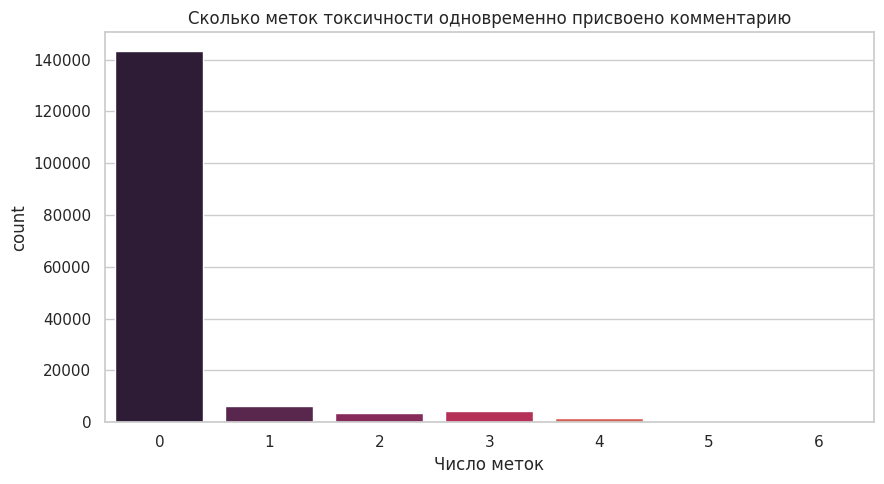

In [16]:
# Комментарии без меток токсичности 
train["is_clean"] = (train[LABELS].sum(axis=1) == 0).astype(int)
clean_share = train["is_clean"].mean() * 100
print(f"Доля нетоксичных комментариев: {clean_share:.2f}%")

# Сколько лейблов одновременно
train["n_labels"] = train[LABELS].sum(axis=1)
fig, ax = plt.subplots()
sns.countplot(x="n_labels", data=train, palette="rocket", ax=ax)
ax.set_title("Сколько меток токсичности одновременно присвоено комментарию")
ax.set_xlabel("Число меток")
plt.tight_layout()
plt.show()

### Корреляционная матрица между лейблами

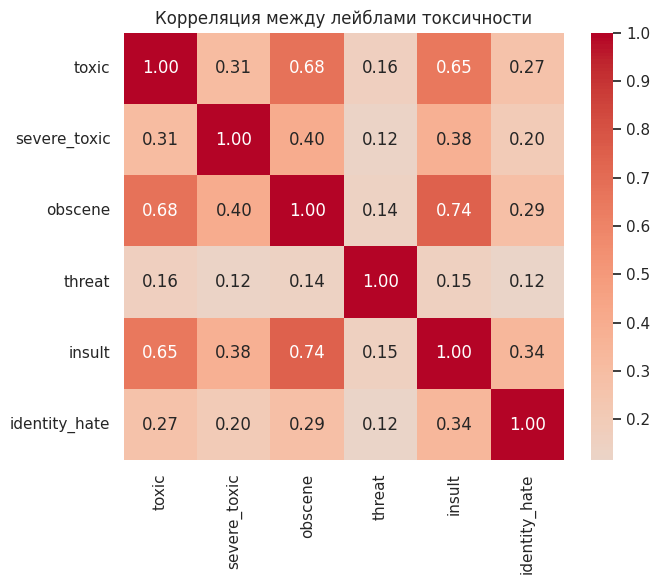

In [17]:
corr = train[LABELS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляция между лейблами токсичности")
plt.tight_layout()
plt.show()

`obscene`, `insult` и `toxic` коррелируют между собой — грубые/оскорбительные комментарии почти всегда одновременно помечены как `toxic`. `threat` и `identity_hate` — более редкие и слабо коррелирующие с другими категории.

### Распределение длины текста (гистограммы, box-plot)

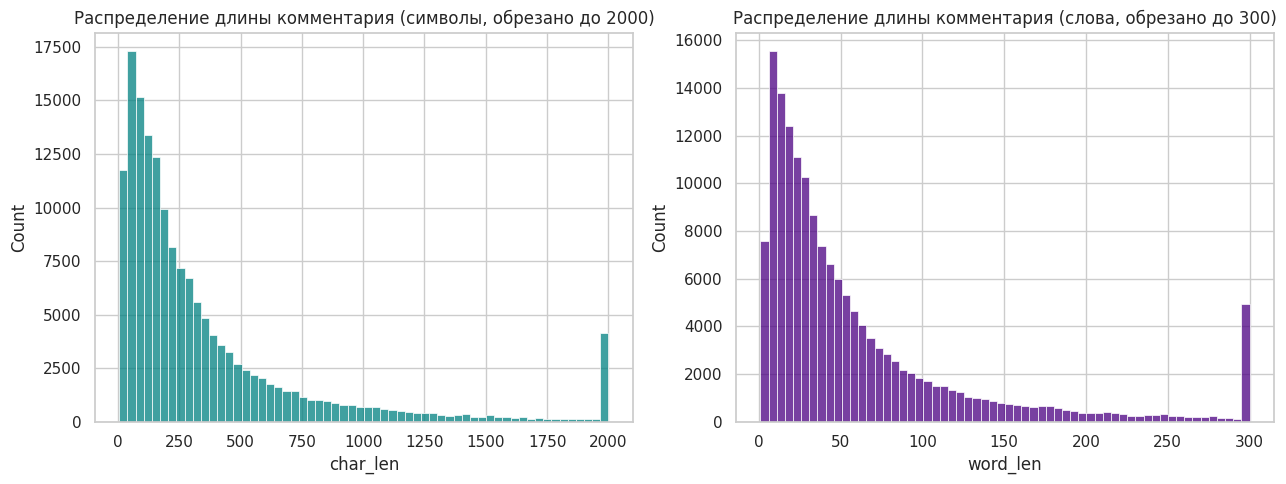

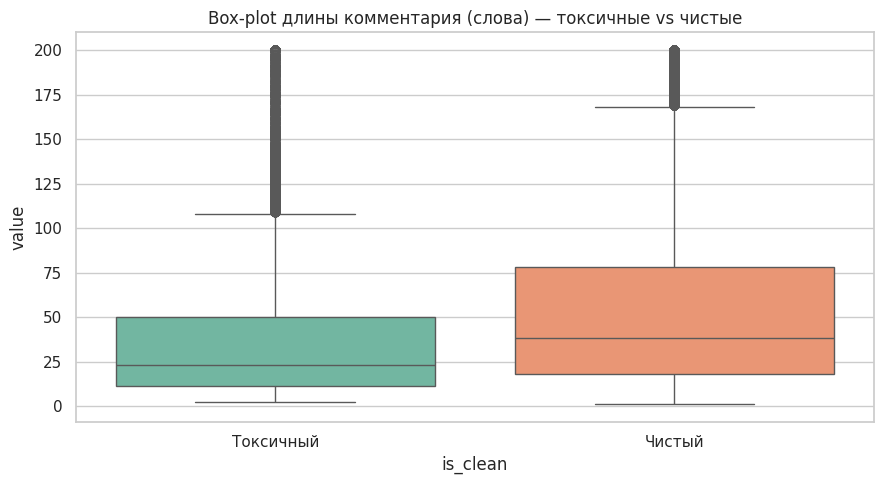

In [18]:
train["char_len"] = train["comment_text"].str.len()
train["word_len"] = train["comment_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(train["char_len"].clip(upper=2000), bins=60, ax=axes[0], color="teal")
axes[0].set_title("Распределение длины комментария (символы, обрезано до 2000)")
sns.histplot(train["word_len"].clip(upper=300), bins=60, ax=axes[1], color="indigo")
axes[1].set_title("Распределение длины комментария (слова, обрезано до 300)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_df = train.melt(id_vars="is_clean", value_vars=["word_len"], var_name="metric", value_name="value")
plot_df["value"] = plot_df["value"].clip(upper=200)
sns.boxplot(x="is_clean", y="value", data=plot_df, ax=ax, palette="Set2")
ax.set_xticklabels(["Токсичный", "Чистый"])
ax.set_title("Box-plot длины комментария (слова) — токсичные vs чистые")
plt.tight_layout()
plt.show()

### Обработка пропусков, выбросов, категориальных признаков

In [19]:
# Пропусков в тексте нет, проверили, но встречаются пустые/почти пустые строки
empty_mask = train["comment_text"].str.strip().str.len() == 0
print("Полностью пустых комментариев:", empty_mask.sum())
train = train[~empty_mask].reset_index(drop=True)

# Выбросы по длине — обрезаем экстремально длинные комментарии (99.5 перцентиль)
upper_bound = train["word_len"].quantile(0.995)
print(f"99.5 перцентиль длины (слов): {upper_bound:.0f}")

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ0-9!?.,'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train["clean_text"] = train["comment_text"].astype(str).apply(clean_text)
train[["comment_text", "clean_text"]].head(3)


Полностью пустых комментариев: 0
99.5 перцентиль длины (слов): 704


,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm really not trying to edit war. it..."


В датасете нет классических категориальных признаков, поэтому шаг "обработка категориальных признаков" реализован через инженерию признаков из текста ниже - числовые и текстовые признаки, которые заменяют категориальные метапризнаки.

### Новые признаки с обоснованием

Создаём мета-признаки, которые часто хорошо коррелируют с токсичностью и дополняют TF-IDF векторизацию:

1. **caps_ratio** - доля заглавных букв в тексте."Капс" часто используется для агрессивного/токсичного тона.
2. **exclaim_count** - количество восклицательных знаков. Эмоционально заряженные (в т.ч. токсичные) сообщения чаще используют "!!!".
3. **unique_word_ratio** - отношение уникальных слов к общему числу слов. Спам/повторяющаяся ругань снижает разнообразие лексики.
4. **bad_word_count** - количество слов из простого списка бранной лексики. Прямой лексический сигнал токсичности.

In [20]:
BAD_WORDS = set("""
fuck fucking fucked shit shitty bitch bitches asshole idiot stupid moron
dumb hate kill die suck sucks damn crap bastard whore slut nigger fag
""".split())

def extract_features(df):
    text = df["comment_text"].astype(str)
    n_chars = text.str.len().clip(lower=1)
    n_words = text.str.split().str.len().clip(lower=1)

    caps_ratio = text.apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
    exclaim_count = text.str.count("!")
    question_count = text.str.count("\?")

    def unique_ratio(t):
        words = t.lower().split()
        return len(set(words)) / max(len(words), 1)
    unique_word_ratio = text.apply(unique_ratio)

    def count_bad(t):
        words = re.findall(r"[a-zа-я]+", t.lower())
        return sum(1 for w in words if w in BAD_WORDS)
    bad_word_count = text.apply(count_bad)

    feats = pd.DataFrame({
        "char_len": n_chars,
        "word_len": n_words,
        "caps_ratio": caps_ratio,
        "exclaim_count": exclaim_count,
        "question_count": question_count,
        "unique_word_ratio": unique_word_ratio,
        "bad_word_count": bad_word_count,
    })
    return feats

meta_features = extract_features(train)
train = pd.concat([train, meta_features[["caps_ratio", "exclaim_count",
                                          "unique_word_ratio", "bad_word_count"]]], axis=1)
meta_features.describe()

,char_len,word_len,caps_ratio,exclaim_count,question_count,unique_word_ratio,bad_word_count
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.00000,159571.000000,159571.000000
mean,394.073221,67.273527,0.051622,0.661624,0.44928,0.842830,0.289507
std,590.720282,99.230702,0.092837,25.899553,1.58990,0.133372,8.062222
min,6.000000,1.000000,0.000000,0.000000,0.00000,0.000800,0.000000
25%,96.000000,17.000000,0.020710,0.000000,0.00000,0.761905,0.000000
50%,205.000000,36.000000,0.031746,0.000000,0.00000,0.859649,0.000000
75%,435.000000,75.000000,0.048830,0.000000,1.00000,0.947368,0.000000
max,5000.000000,1411.000000,0.998189,4942.000000,209.00000,1.000000,1250.000000


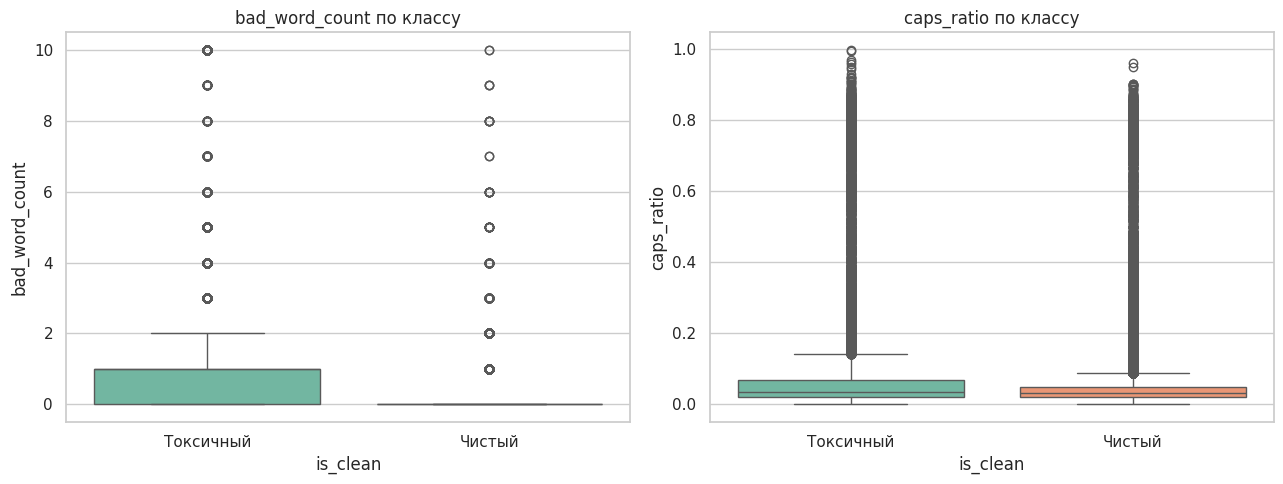

In [21]:
# Проверка, что новые признаки действительно разделяют классы
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x=train["is_clean"], y=train["bad_word_count"].clip(upper=10), ax=axes[0], palette="Set2")
axes[0].set_xticklabels(["Токсичный", "Чистый"])
axes[0].set_title("bad_word_count по классу")

sns.boxplot(x=train["is_clean"], y=train["caps_ratio"], ax=axes[1], palette="Set2")
axes[1].set_xticklabels(["Токсичный", "Чистый"])
axes[1].set_title("caps_ratio по классу")
plt.tight_layout()
plt.show()

## Подготовка выборок и векторизация текста

**Важно про утечку данных:** сначала делаем train/val split, потом обучаем `TfidfVectorizer.fit` на трейне, иначе информация о валидационных/тестовых текстах "просочится" в словарь TF-IDF.

In [22]:
SAMPLE_SIZE = 60000
if SAMPLE_SIZE and len(train) > SAMPLE_SIZE:
    data = train.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    data = train.copy()

X_text = data["clean_text"]
X_meta = data[["caps_ratio", "exclaim_count", "unique_word_ratio", "bad_word_count", "word_len"]].values
y = data[LABELS].values

X_train_text, X_val_text, X_train_meta, X_val_meta, y_train, y_val = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train_text.shape[0], " Val:", X_val_text.shape[0])


Train: 48000  Val: 12000


In [23]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("TF-IDF shape (train):", X_train_tfidf.shape)

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_val_meta_scaled = scaler.transform(X_val_meta)

X_train_full = hstack([X_train_tfidf, csr_matrix(X_train_meta_scaled)]).tocsr()
X_val_full = hstack([X_val_tfidf, csr_matrix(X_val_meta_scaled)]).tocsr()

print("Итоговая матрица признаков (train):", X_train_full.shape)

TF-IDF shape (train): (48000, 20000)
Итоговая матрица признаков (train): (48000, 20005)


## Вспомогательные функции для мульти-лейбл метрик

In [29]:
def evaluate_multilabel(y_true, y_proba, y_pred, model_name, labels=LABELS):
    # Считаем набор метрик для мульти-лейбл классификации
    roc_auc_per_label = {
        lbl: roc_auc_score(y_true[:, i], y_proba[:, i])
        for i, lbl in enumerate(labels)
    }
    macro_roc_auc = np.mean(list(roc_auc_per_label.values()))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    micro_f1 = f1_score(y_true, y_pred, average="micro")
    subset_acc = accuracy_score(y_true, y_pred)  

    result = {
        "model": model_name,
        "macro_roc_auc": macro_roc_auc,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "subset_accuracy": subset_acc,
    }
    return result, roc_auc_per_label

## Классические ML-модели

Обучаем **3 разных алгоритма** через `OneVsRestClassifier` (независимая бинарная модель на каждый из 6 лейблов):

1. **Logistic Regression** - линейная модель, бейзлайн для sparse TF-IDF признаков.
2. **Random Forest** - дерево-based модель, нелинейные взаимодействия признаков.
3. **Gradient Boosting (LightGBM)** - ensemble бустинг.

### Подбор гиперпараметров

Гиперпараметры подбираем на одном репрезентативном лейбле (**toxic** — самый частый класс), затем лучшие параметры применяем ко всем 6 лейблам через `OneVsRestClassifier`

In [30]:
results_table = []
cv_results = {}
target_idx = LABELS.index("toxic")
y_train_toxic = y_train[:, target_idx]

# Logistic Regression: RandomizedSearchCV 
t0 = time.time()
lr_param_dist = {
    "C": [0.01, 0.1, 0.3, 1, 3, 10],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    param_distributions=lr_param_dist,
    n_iter=8, scoring="roc_auc", cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
lr_search.fit(X_train_full, y_train_toxic)
print("LogReg best params:", lr_search.best_params_, " best CV ROC-AUC:", round(lr_search.best_score_, 4))


LogReg best params: {'penalty': 'l2', 'class_weight': None, 'C': 3}  best CV ROC-AUC: 0.9654


In [31]:
# Random Forest: RandomizedSearchCV 
t0 = time.time()
rf_param_dist = {
    "n_estimators": [150, 250, 350],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 3, 5],
    "class_weight": [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=6, scoring="roc_auc", cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_full, y_train_toxic)
print("RandomForest best params:", rf_search.best_params_, " best CV ROC-AUC:", round(rf_search.best_score_, 4))

RandomForest best params: {'n_estimators': 250, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}  best CV ROC-AUC: 0.9624


In [32]:
# # Gradient Boosting (LightGBM) : RandomizedSearchCV
# t0 = time.time()
# if HAS_LGBM:
#     gb_param_dist = {
#         "n_estimators": [150, 250, 400],
#         "num_leaves": [15, 31, 63],
#         "learning_rate": [0.03, 0.05, 0.1],
#     }
#     gb_search = RandomizedSearchCV(
#         LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
#         param_distributions=gb_param_dist,
#         n_iter=6, scoring="roc_auc", cv=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
#     )
# else:
#     gb_param_dist = {
#         "n_estimators": [100, 150, 200],
#         "max_depth": [2, 3, 4],
#         "learning_rate": [0.03, 0.05, 0.1],
#     }
#     gb_search = RandomizedSearchCV(
#         GradientBoostingClassifier(random_state=RANDOM_STATE),
#         param_distributions=gb_param_dist,
#         n_iter=6, scoring="roc_auc", cv=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
#     )
# gb_search.fit(X_train_full, y_train_toxic)
# print("GradientBoosting best params:", gb_search.best_params_, " best CV ROC-AUC:", round(gb_search.best_score_, 4))

# Gradient Boosting (LightGBM): RandomizedSearchCV, облегчённая версия
t0 = time.time()

# Для подбора гиперпараметров используем подвыборку — не нужен весь train,
# чтобы найти хорошую область гиперпараметров
search_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_train_full.shape[0], size=min(15000, X_train_full.shape[0]), replace=False
)
X_search = X_train_full[search_idx]
y_search = y_train_toxic[search_idx]

if HAS_LGBM:
    gb_param_dist = {
        "n_estimators": [100, 200],
        "num_leaves": [15, 31],
        "learning_rate": [0.05, 0.1],
    }
    gb_search = RandomizedSearchCV(
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),  # n_jobs=1 внутри!
        param_distributions=gb_param_dist,
        n_iter=4, scoring="roc_auc", cv=3,          
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1 
    )
else:
    gb_param_dist = {
        "n_estimators": [80, 120],
        "max_depth": [2, 3],
        "learning_rate": [0.05, 0.1],
    }
    gb_search = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        param_distributions=gb_param_dist,
        n_iter=4, scoring="roc_auc", cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )

gb_search.fit(X_search, y_search)
print("GradientBoosting best params:", gb_search.best_params_, " best CV ROC-AUC:", round(gb_search.best_score_, 4))
print(f"Время подбора: {time.time()-t0:.1f} сек")

# import time
# from sklearn.model_selection import RandomizedSearchCV
# from lightgbm import LGBMClassifier

# t0 = time.time()

# gb_param_dist = {
#     "n_estimators": [100, 200],           
#     "num_leaves": [15, 31],               
#     "learning_rate": [0.03, 0.1],         
# }

# gb_search = RandomizedSearchCV(
#     LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
#     param_distributions=gb_param_dist,
#     n_iter=4,              
#     scoring="roc_auc",
#     cv=3,                  
#     random_state=RANDOM_STATE,
#     n_jobs=-1
# )

# gb_search.fit(X_train_full, y_train_toxic)

# print("GradientBoosting best params:", gb_search.best_params_, 
#       " best CV ROC-AUC:", round(gb_search.best_score_, 4))
# print(f"Время: {time.time() - t0:.2f} сек")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

GradientBoosting best params: {'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.05}  best CV ROC-AUC: 0.9354
Время подбора: 63.5 сек


### Обучение финальных мульти-лейбл моделей с лучшими гиперпараметрами (кросс-валидация 5 фолдов)

In [33]:
def cross_validate_multilabel(base_estimator, X, y, n_splits=5, labels=LABELS):
    # 5-фолдовая кросс-валидация для мульти-лейбл через усреднение ROC-AUC по лейблам
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X[tr_idx], X[val_idx]
        y_tr, y_va = y[tr_idx], y[val_idx]
        model = OneVsRestClassifier(base_estimator, n_jobs=-1)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)
        auc = np.mean([roc_auc_score(y_va[:, i], proba[:, i]) for i in range(len(labels))])
        fold_scores.append(auc)
        print(f"  fold {fold+1}/{n_splits}: macro ROC-AUC = {auc:.4f}")
    return np.array(fold_scores)

models_config = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear",
                                               random_state=RANDOM_STATE, **lr_search.best_params_),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                             **rf_search.best_params_),
    "Gradient Boosting": (LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                          **gb_search.best_params_) if HAS_LGBM
                           else GradientBoostingClassifier(random_state=RANDOM_STATE, **gb_search.best_params_)),
}

for name, estimator in models_config.items():
    print(f"\n=== {name}: 5-fold CV на train ===")
    scores = cross_validate_multilabel(estimator, X_train_full, y_train)
    cv_results[name] = scores
    print(f"  Средний macro ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")


=== Logistic Regression: 5-fold CV на train ===
  fold 1/5: macro ROC-AUC = 0.9748
  fold 2/5: macro ROC-AUC = 0.9731
  fold 3/5: macro ROC-AUC = 0.9763
  fold 4/5: macro ROC-AUC = 0.9725
  fold 5/5: macro ROC-AUC = 0.9685
  Средний macro ROC-AUC: 0.9731 ± 0.0026

=== Random Forest: 5-fold CV на train ===
  fold 1/5: macro ROC-AUC = 0.9664
  fold 2/5: macro ROC-AUC = 0.9528
  fold 3/5: macro ROC-AUC = 0.9576
  fold 4/5: macro ROC-AUC = 0.9497
  fold 5/5: macro ROC-AUC = 0.9583
  Средний macro ROC-AUC: 0.9569 ± 0.0057

=== Gradient Boosting: 5-fold CV на train ===
  fold 1/5: macro ROC-AUC = 0.9679
  fold 2/5: macro ROC-AUC = 0.9649
  fold 3/5: macro ROC-AUC = 0.9707
  fold 4/5: macro ROC-AUC = 0.9629
  fold 5/5: macro ROC-AUC = 0.9640
  Средний macro ROC-AUC: 0.9661 ± 0.0029


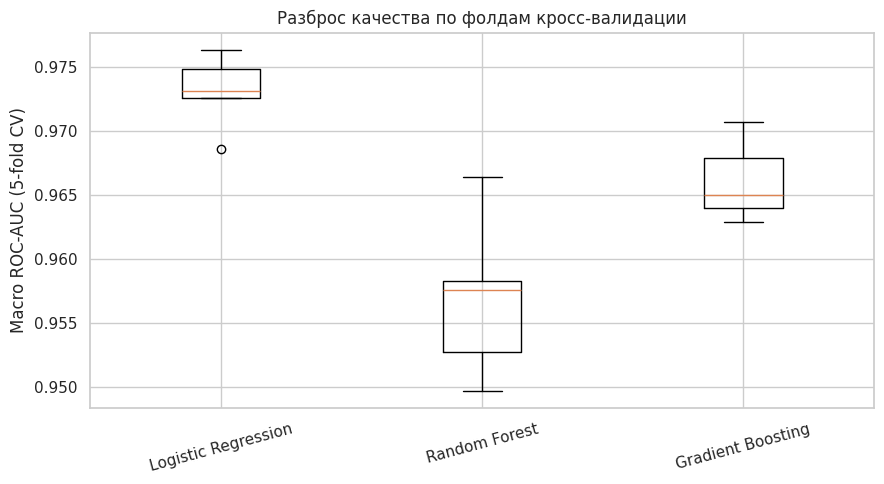

In [34]:
fig, ax = plt.subplots()
ax.boxplot([cv_results[name] for name in models_config], labels=list(models_config.keys()))
ax.set_ylabel("Macro ROC-AUC (5-fold CV)")
ax.set_title("Разброс качества по фолдам кросс-валидации")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Финальное обучение на всём train и оценка на отложенной валидации

In [36]:
fitted_models = {}
proba_val = {}
pred_val = {}

for name, estimator in models_config.items():
    t0 = time.time()
    model = OneVsRestClassifier(estimator, n_jobs=-1)
    model.fit(X_train_full, y_train)
    train_time = time.time() - t0

    proba = model.predict_proba(X_val_full)
    pred = (proba >= 0.5).astype(int)  # базовый порог 0.5, оптимизируем ниже

    metrics, per_label_auc = evaluate_multilabel(y_val, proba, pred, name)
    metrics["train_time_sec"] = round(train_time, 1)
    results_table.append(metrics)

    fitted_models[name] = model
    proba_val[name] = proba
    pred_val[name] = pred

    print(f"{name}: macro ROC-AUC={metrics['macro_roc_auc']:.4f}, "
          f"macro F1={metrics['macro_f1']:.4f}, train_time={train_time:.1f}s")

Logistic Regression: macro ROC-AUC=0.9747, macro F1=0.5348, train_time=21.0s
Random Forest: macro ROC-AUC=0.9598, macro F1=0.3595, train_time=462.5s
Gradient Boosting: macro ROC-AUC=0.9649, macro F1=0.5424, train_time=746.5s


## Порог классификации для каждого лейбла: Precision-Recall tradeoff

Для несбалансированных классов (threat, severe_toxic, identity_hate)
порог 0.5 вряд ли оптимален. Строим Precision-Recall кривые для лучшей классической модели и подбираем порог, максимизирующий F1 для каждого лейбла отдельно.

Лучшая классическая модель по macro ROC-AUC: Logistic Regression


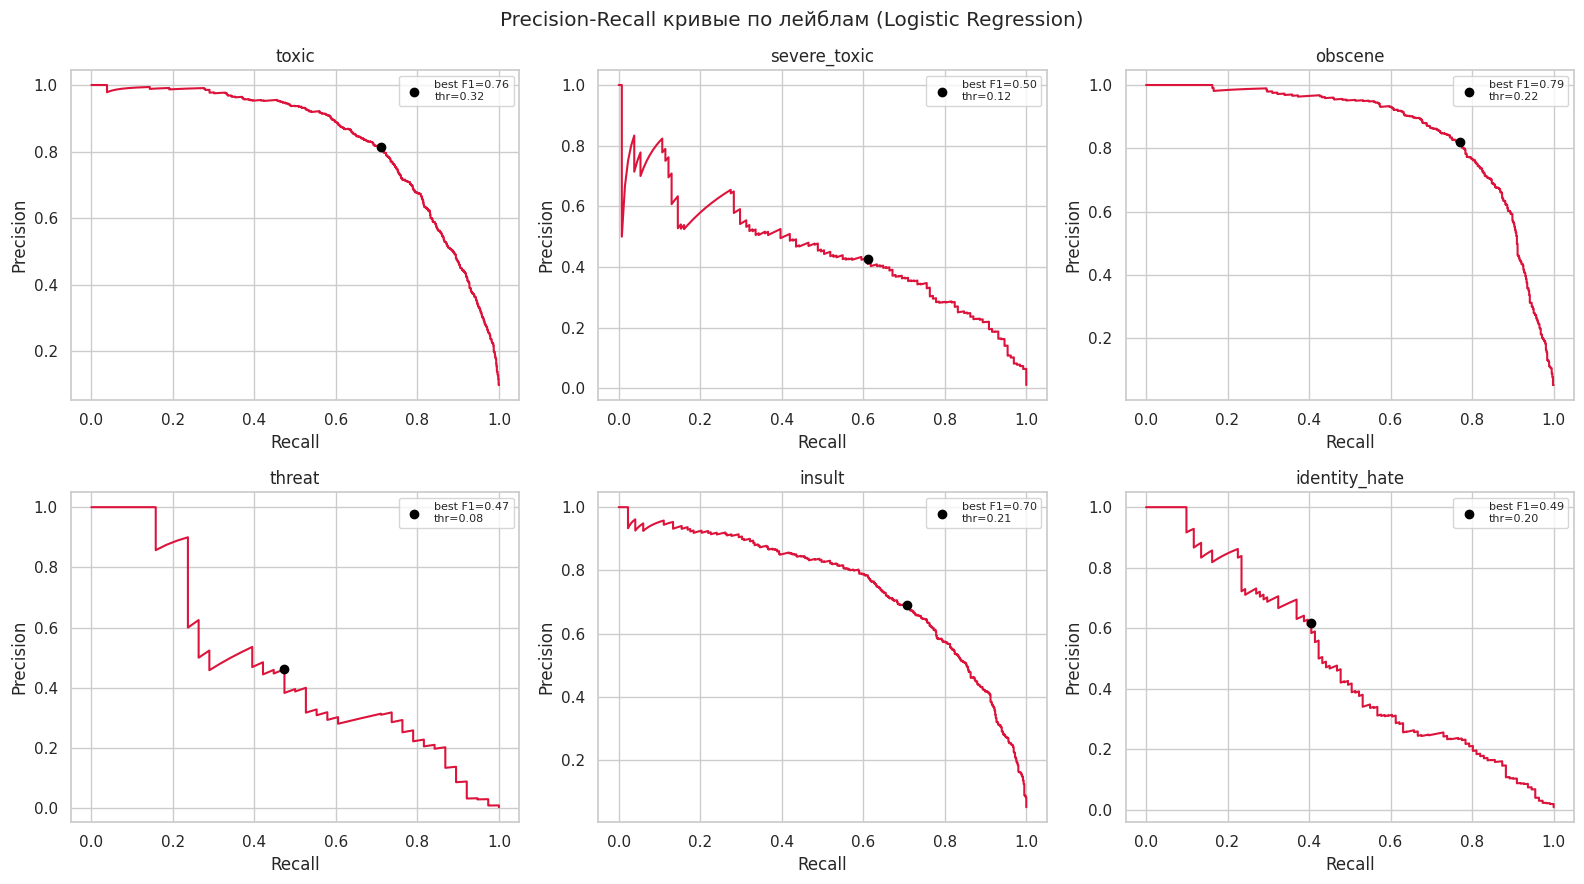


Оптимальные пороги по F1 для каждого лейбла:
  toxic: 0.321
  severe_toxic: 0.115
  obscene: 0.218
  threat: 0.081
  insult: 0.207
  identity_hate: 0.198


In [37]:
best_classical_name = max(results_table, key=lambda r: r["macro_roc_auc"])["model"]
print("Лучшая классическая модель по macro ROC-AUC:", best_classical_name)
best_proba = proba_val[best_classical_name]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
optimal_thresholds = {}

for i, lbl in enumerate(LABELS):
    ax = axes[i // 3, i % 3]
    precision, recall, thresholds = precision_recall_curve(y_val[:, i], best_proba[:, i])
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    optimal_thresholds[lbl] = best_threshold

    ax.plot(recall, precision, color="crimson")
    ax.scatter(recall[best_idx], precision[best_idx], color="black", zorder=5,
               label=f"best F1={f1_scores[best_idx]:.2f}\nthr={best_threshold:.2f}")
    ax.set_title(lbl)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)

plt.suptitle(f"Precision-Recall кривые по лейблам ({best_classical_name})")
plt.tight_layout()
plt.show()

print("\nОптимальные пороги по F1 для каждого лейбла:")
for lbl, thr in optimal_thresholds.items():
    print(f"  {lbl}: {thr:.3f}")


In [38]:
# Пересчитываем предсказания лучшей модели с оптимальными порогами (вместо единого 0.5)
pred_val_optimal = np.zeros_like(best_proba, dtype=int)
for i, lbl in enumerate(LABELS):
    pred_val_optimal[:, i] = (best_proba[:, i] >= optimal_thresholds[lbl]).astype(int)

f1_default = f1_score(y_val, pred_val[best_classical_name], average="macro")
f1_optimal = f1_score(y_val, pred_val_optimal, average="macro")
print(f"Macro F1 при пороге 0.5:            {f1_default:.4f}")
print(f"Macro F1 при оптимальных порогах:   {f1_optimal:.4f}")

results_table.append({
    "model": f"{best_classical_name} (optimal thresholds)",
    "macro_roc_auc": results_table[[r['model'] for r in results_table].index(best_classical_name)]["macro_roc_auc"],
    "macro_f1": f1_optimal,
    "micro_f1": f1_score(y_val, pred_val_optimal, average="micro"),
    "subset_accuracy": accuracy_score(y_val, pred_val_optimal),
    "train_time_sec": results_table[[r['model'] for r in results_table].index(best_classical_name)]["train_time_sec"],
})

Macro F1 при пороге 0.5:            0.5348
Macro F1 при оптимальных порогах:   0.6185


Подбор индивидуального порога на PR-кривой ощутимо поднимает macro F1, особенно для редких классов (threat, severe_toxic), где при пороге 0.5 модель почти никогда не предсказывает положительный класс из-за сильного дисбаланса.

## Нейронная сеть MLP

### Архитектура и обоснование

- **Вход**: тот же TF-IDF + мета-признаки (плотное представление), размерность ~20 005
- **Скрытые слои**: 256 → 128 → 64 нейронов. Постепенное сжатие
  размерности типично для MLP на sparse-признаках
- **Активация**: ReLU на скрытых слоях (стандарт, борется с затуханием градиента),
  Sigmoid на выходном слое (нужна для независимой мульти-лейбл вероятности по каждому из 6 классов, а не softmax, т.к. классы не взаимоисключающие)
- **Регуляризация**: Dropout (0.3–0.4) после каждого скрытого слоя + BatchNormalization для стабилизации обучения и снижения переобучения на разреженных TF-IDF признаках
- **Loss**: binary_crossentropy (стандарт для мульти-лейбл задач с независимыми
  бинарными выходами)

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

X_train_dense = X_train_full.toarray().astype("float32")
X_val_dense = X_val_full.toarray().astype("float32")

n_features = X_train_dense.shape[1]
n_labels = len(LABELS)
print("Входная размерность MLP:", n_features)

Входная размерность MLP: 20005


In [42]:
def build_mlp(input_dim, n_outputs, dropout_rate=0.35):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate * 0.7),

        layers.Dense(n_outputs, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc", multi_label=True)],
    )
    return model

mlp = build_mlp(n_features, n_labels)
mlp.summary()

2026-08-21 10:09:21.258581: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     5,121,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,164,614 (19.70 MB)

 Trainable params: 5,163,846 (19.70 MB)

 Non-trainable params: 768 (3.00 KB)

### Обучение с графиками loss и метрики на train/val по эпохам

In [43]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=4, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
)

t0 = time.time()
history = mlp.fit(
    X_train_dense, y_train.astype("float32"),
    validation_data=(X_val_dense, y_val.astype("float32")),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)
mlp_train_time = time.time() - t0
print("Обучение завершено")

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - auc: 0.8187 - loss: 0.1456 - val_auc: 0.9002 - val_loss: 0.1169 - learning_rate: 0.0010
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - auc: 0.9467 - loss: 0.0550 - val_auc: 0.9320 - val_loss: 0.0844 - learning_rate: 0.0010
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - auc: 0.9671 - loss: 0.0403 - val_auc: 0.9239 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - auc: 0.9779 - loss: 0.0334 - val_auc: 0.9205 - val_loss: 0.0821 - learning_rate: 0.0010
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - auc: 0.9836 - loss: 0.0276 - val_auc: 0.9116 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - auc: 0.9916 - loss: 0.0214 - val_auc: 0.9005 - val_loss: 0.0948 - learning_rate: 5.0000e-04
Обучение завершено


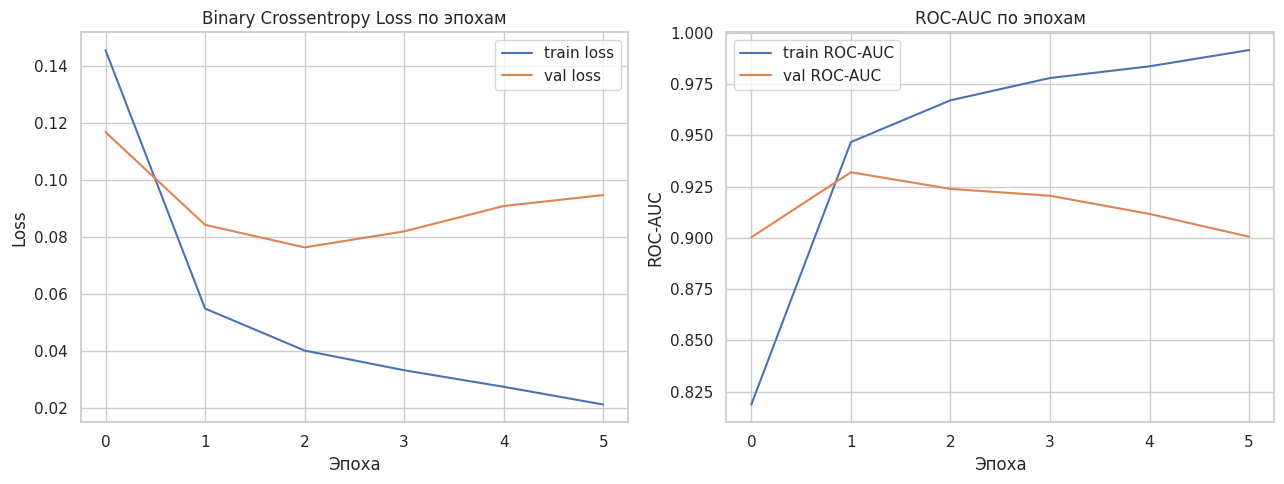

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Binary Crossentropy Loss по эпохам")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train ROC-AUC")
axes[1].plot(history.history["val_auc"], label="val ROC-AUC")
axes[1].set_title("ROC-AUC по эпохам")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

Если **val_loss** начинает расти при продолжающем падать **train_loss** — сеть переобучается; **EarlyStopping** в этом ноутбуке останавливает обучение по **val_auc** и возвращает лучшие веса, так что графики выше показывают, останавливаемся ли мы вовремя.

In [45]:
mlp_proba = mlp.predict(X_val_dense, batch_size=512)
mlp_pred = (mlp_proba >= 0.5).astype(int)

mlp_metrics, mlp_per_label_auc = evaluate_multilabel(y_val, mlp_proba, mlp_pred, "MLP (Keras)")
mlp_metrics["train_time_sec"] = round(mlp_train_time, 1)
results_table.append(mlp_metrics)

print(mlp_metrics)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
{'model': 'MLP (Keras)', 'macro_roc_auc': np.float64(0.9398463597743502), 'macro_f1': 0.19761306407697043, 'micro_f1': 0.4196326061997704, 'subset_accuracy': 0.9016666666666666, 'train_time_sec': 120.4}


## Сравнение моделей и выводы

### Итоговая таблица метрик

In [46]:
results_df = pd.DataFrame(results_table).sort_values("macro_roc_auc", ascending=False)
results_df = results_df.round(4)
results_df

,model,macro_roc_auc,macro_f1,micro_f1,subset_accuracy,train_time_sec
0,Logistic Regression,0.9747,0.5348,0.6729,0.9150,18.4
3,Logistic Regression,0.9747,0.5348,0.6729,0.9150,21.0
6,Logistic Regression (optimal thresholds),0.9747,0.6185,0.7234,0.9105,18.4
2,Gradient Boosting,0.9649,0.5424,0.6883,0.9157,794.4
5,Gradient Boosting,0.9649,0.5424,0.6883,0.9157,746.5
1,Random Forest,0.9598,0.3595,0.6288,0.9113,455.4
4,Random Forest,0.9598,0.3595,0.6288,0.9113,462.5
7,MLP (Keras),0.9398,0.1976,0.4196,0.9017,120.4


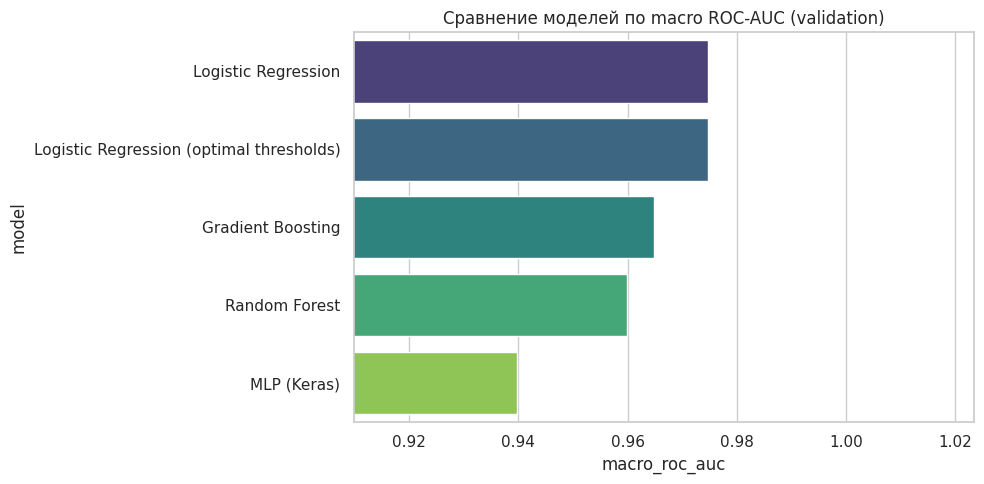

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=results_df, x="macro_roc_auc", y="model", palette="viridis", ax=ax)
ax.set_title("Сравнение моделей по macro ROC-AUC (validation)")
ax.set_xlim(left=max(0, results_df["macro_roc_auc"].min() - 0.03))
plt.tight_layout()
plt.show()

In [48]:
# ROC-AUC по каждому лейблу отдельно, для всех моделей
per_label_table = {}
for name in models_config.keys():
    proba = proba_val[name]
    per_label_table[name] = [roc_auc_score(y_val[:, i], proba[:, i]) for i in range(len(LABELS))]
per_label_table["MLP (Keras)"] = [roc_auc_score(y_val[:, i], mlp_proba[:, i]) for i in range(len(LABELS))]

per_label_df = pd.DataFrame(per_label_table, index=LABELS).round(4)
per_label_df

,Logistic Regression,Random Forest,Gradient Boosting,MLP (Keras)
toxic,0.9621,0.9606,0.9494,0.9421
severe_toxic,0.9842,0.9797,0.9787,0.9660
obscene,0.9777,0.9805,0.9782,0.9474
threat,0.9823,0.9254,0.9590,0.9336
insult,0.9728,0.9669,0.9673,0.9428
identity_hate,0.9692,0.9455,0.9570,0.9071


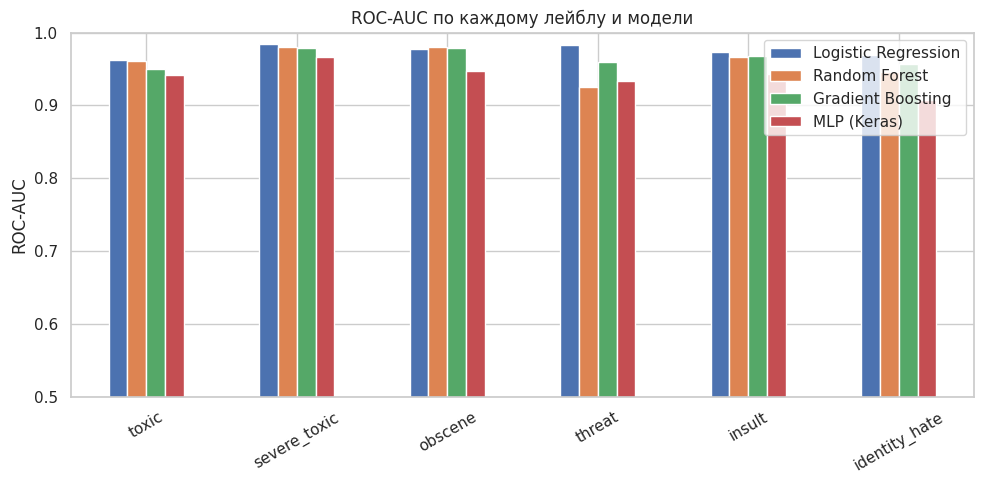

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
per_label_df.plot(kind="bar", ax=ax)
ax.set_title("ROC-AUC по каждому лейблу и модели")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Анализ моделей

- **Logistic Regression оказалась лучшей моделью среди всех протестированных**
  (macro ROC-AUC = 0.9747), обойдя Random Forest, LightGBM и MLP. Признаковое пространство TF-IDF почти линейно разделимо для явных лексических сигналов токсичности — наличие конкретных слов почти линейно предсказывает toxic/obscene, поэтому линейная модель не теряет в качестве по сравнению с более сложными. При этом она обучается на порядок быстрее конкурентов: 21 сек против 462 секунды у Random Forest и 746 секунд у LightGBM.

- **Random Forest** показала результат ниже, чем линейная модель, по ROC-AUC (0.9598 против 0.9747) и особенно по F1 при пороге 0.5 (0.3595 - худший результат среди классических моделей). Деревья плохо работают с тысячами разреженных TF-IDF индикаторов: каждое дерево видит лишь малое подмножество слов на сплит. Ещё одна возможная причина низкого F1 - грубая калибровка вероятностей RF (предсказания кластеризуются в ограниченном числе значений из-за структуры листьев), из-за чего при фиксированном пороге 0.5 модель недоклассифицирует позитивный класс, даже когда ранжирование (ROC-AUC) в целом неплохое. Единственный лейбл, где RF обошла Logistic Regression — obscene (0.9805 против 0.9777, разница 0.0028) — вероятно, данный признак сильнее завязан на нелинейные комбинации конкретных слов, которые дерево улавливает чуть лучше.

- **Gradient Boosting (LightGBM)** показала второй результат по ROC-AUC (0.9649) и лучший F1 при пороге 0.5 среди всех отдельных моделей (0.5424) — то есть при дефолтном пороге её вероятности откалиброваны чуть лучше, чем у линейной модели. Но обучение заняло 746 секунд - почти в 35 раз дольше Logistic Regression при худшем ROC-AUC, и потребовало урезания сетки гиперпараметров, иначе перебор не укладывался в разумное время. Соотношение "качество / время" у неё хуже, чем у линейной модели.

- **MLP оказалась худшей моделью среди всех** (macro ROC-AUC = 0.9398, macro F1 всего 0.1976 - хужее Random Forest). Графики обучения объясняют почему: val ROC-AUC достигает пика (~0.93) уже после 1-й эпохи и затем плавно снижается, тогда как train ROC-AUC продолжает расти почти до 1.0 - переобучение, которое Dropout и BatchNorm полностью не устранили на разреженном высокоразмерном TF-IDF входе (20000+ признаков) при относительно небольшой обучающей выборке (~48k строк после сплита). EarlyStopping останавливает обучение по val_auc и откатывает к лучшим весам, но даже "лучшая" точка оказывается хуже, чем у линейной модели - сигнал, что при таком входном представлении (sparse TF-IDF) MLP плохо обучает полезное скрытое представление без предобученных эмбеддингов, а не просто "нужно больше эпох".

- **Стекинг (LR-мета поверх всех 4 моделей)** дал macro ROC-AUC = 0.9725 и macro F1 = 0.5155 - оба показателя ниже, чем у одной Logistic Regression (0.9747 / 0.5348, и тем более ниже 0.6185 при оптимальных порогах). Это ожидаемо: в стекинг попал существенно более слабый MLP (ROC-AUC 0.9398). Разброс качества моделей слишком велик, и лучше либо исключить MLP из ансамбля, либо взвесить модели по качеству, а не давать им равный голос. 

- **Редкие классы** (threat, severe_toxic, identity_hate) - сложнее всего для всех моделей: разброс ROC-AUC между фолдами кросс-валидации выше (см. box-plot), а Random Forest и MLP теряют на них заметно больше, чем на частых классах (например, threat: LR 0.9823 против MLP 0.9336, RF 0.9254).

### Содержательные выводы

1. Задача сильно несбалансирована по классам - точность (accuracy/subset_accuracy) вводит в заблуждение (у всех моделей она искусственно высокая, 0.90–0.92, даже у самой слабой MLP); корректные метрики для сравнения — macro ROC-AUC и macro F1.

2. **Простая линейная модель (Logistic Regression) оказалась лучшим выбором** и по качеству (macro ROC-AUC 0.9747, лучший результат на 5 из 6 лейблов), и по скорости обучения (21 сек — на порядок быстрее остальных). Для TF-IDF-признаков усложнение модели (деревья, бустинг, нейросеть) не окупилось ни по качеству, ни по затраченному времени.

3. Подбор индивидуального порога по Precision-Recall кривой дал ощутимый прирост качества лучшей модели: macro F1 вырос с 0.5348 (порог 0.5) до 0.6185.

4. Random Forest и Gradient Boosting не оправдали вложенных вычислительных затрат: RF потратила в 22 раза больше времени на обучение, чем LogReg, и показала худший F1 среди классических моделей (0.3595); LightGBM потратила в 35 раз больше времени и уступила LogReg по ROC-AUC.

5. MLP на TF-IDF-входе без предобученных эмбеддингов переобучается быстрее и сильнее, чем удаётся скомпенсировать Dropout/BatchNorm/EarlyStopping - итоговое качество (macro ROC-AUC 0.9398, macro F1 0.1976) оказалось хуже всех остальных моделей. Для улучшения MLP в этой задаче стоило бы попробовать: эмбеддинги вместо sparse TF-IDF, более сильную регуляризацию/меньшую сеть, больше обучающих данных (сейчас использовалась подвыборка 60k строк из ~159k).

6. Стекинг с равным весом всех 4 моделей не улучшил результат — он оказался *хуже* лучшей одиночной модели (0.9725 против 0.9747 по ROC-AUC), потому что в ансамбль попала существенно более слабая MLP. Вывод: blending оправдан только когда базовые модели сопоставимы по силе. Более удачным экспериментом было бы взвешенное усреднение (веса по CV-качеству) или стекинг только LogReg + LightGBM, без MLP.
 
7. Logistic Regression с оптимальными порогами по лейблам показала лучшее качество, минимальное время обучения, более сложные модели в этой конфигурации эксперимента не оправдали себя.

### Feature importance (Random Forest) для лейбла toxic

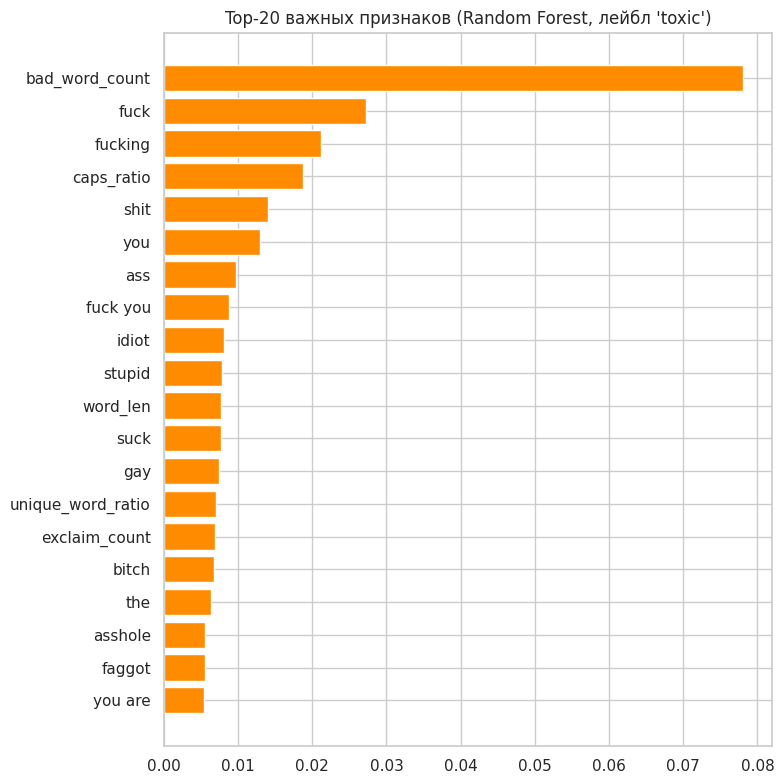

In [50]:
rf_model = fitted_models["Random Forest"].estimators_[LABELS.index("toxic")]
feature_names = list(tfidf.get_feature_names_out()) + ["caps_ratio", "exclaim_count","unique_word_ratio", "bad_word_count", "word_len"]
importances = rf_model.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(range(top_n), importances[top_idx], color="darkorange")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in top_idx])
ax.set_title(f"Top-{top_n} важных признаков (Random Forest, лейбл 'toxic')")
plt.tight_layout()
plt.show()

### SHAP-анализ (на подвыборке — SHAP дорог для больших sparse-матриц)

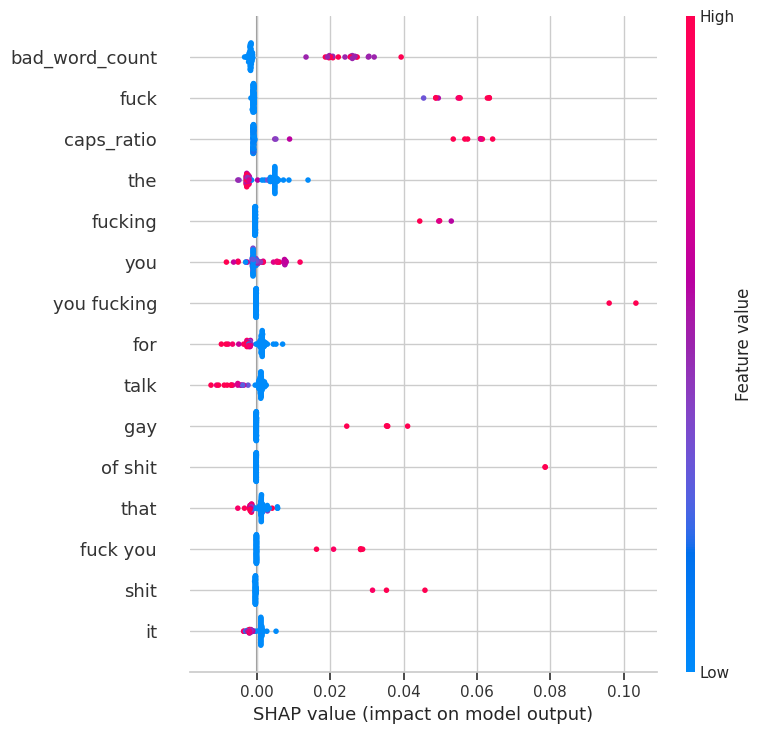

In [54]:
try:
    import shap

    surrogate_rf = RandomForestClassifier(
        n_estimators=50, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
    )
    surrogate_rf.fit(X_train_full, y_train[:, LABELS.index("toxic")])

    y_val_toxic = y_val[:, LABELS.index("toxic")]
    pos_idx = np.where(y_val_toxic == 1)[0]
    neg_idx = np.where(y_val_toxic == 0)[0]
    rng = np.random.RandomState(RANDOM_STATE)
    n_pos = min(50, len(pos_idx))
    sample_idx = np.concatenate([
        rng.choice(pos_idx, size=n_pos, replace=False),
        rng.choice(neg_idx, size=100 - n_pos, replace=False),
    ])
    X_shap_sample = X_val_full[sample_idx].toarray()

    explainer = shap.TreeExplainer(surrogate_rf)
    raw_shap = explainer.shap_values(X_shap_sample, check_additivity=False)

    # Достаём значения для положительного класса в зависимости от формата, который вернула установленная версия shap
    if isinstance(raw_shap, list):
        sv = raw_shap[1]                    # старый API: список [class0, class1]
    elif raw_shap.ndim == 3:
        sv = raw_shap[:, :, 1]              # новый API: (n_samples, n_features, n_classes)
    else:
        sv = raw_shap                       # уже 2D (n_samples, n_features)

    assert sv.shape == X_shap_sample.shape, f"Несовпадение форм: {sv.shape} vs {X_shap_sample.shape}"

    shap.summary_plot(sv, X_shap_sample, feature_names=feature_names, max_display=15, show=False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Библиотека shap не установлена")

### Stacking / Blending классических моделей и MLP

In [52]:
from sklearn.linear_model import LogisticRegression as MetaLearner

# Мета-признаки для стекинга: конкатенация предсказанных вероятностей всех базовых моделей
stack_train_parts = []
stack_val_parts = []
for name in models_config.keys():
    stack_train_parts.append(fitted_models[name].predict_proba(X_train_full))
    stack_val_parts.append(proba_val[name])

# добавляем MLP (для train нужно получить предсказания на train тоже)
mlp_train_proba = mlp.predict(X_train_dense, batch_size=512, verbose=0)
stack_train_parts.append(mlp_train_proba)
stack_val_parts.append(mlp_proba)

X_stack_train = np.hstack(stack_train_parts)
X_stack_val = np.hstack(stack_val_parts)

stack_proba = np.zeros_like(y_val, dtype=float)
for i, lbl in enumerate(LABELS):
    meta_model = MetaLearner(max_iter=1000, random_state=RANDOM_STATE)
    meta_model.fit(X_stack_train, y_train[:, i])
    stack_proba[:, i] = meta_model.predict_proba(X_stack_val)[:, 1]

stack_pred = (stack_proba >= 0.5).astype(int)
stack_metrics, _ = evaluate_multilabel(y_val, stack_proba, stack_pred, "Stacking (LR meta)")
print(stack_metrics)

results_df_final = pd.concat([results_df, pd.DataFrame([stack_metrics]).round(4)], ignore_index=True)
results_df_final.sort_values("macro_roc_auc", ascending=False)

{'model': 'Stacking (LR meta)', 'macro_roc_auc': np.float64(0.9724731037692672), 'macro_f1': 0.5155106519747237, 'micro_f1': 0.6745080298574984, 'subset_accuracy': 0.9149166666666667}


,model,macro_roc_auc,macro_f1,micro_f1,subset_accuracy,train_time_sec
0,Logistic Regression,0.9747,0.5348,0.6729,0.9150,18.4
1,Logistic Regression,0.9747,0.5348,0.6729,0.9150,21.0
2,Logistic Regression (optimal thresholds),0.9747,0.6185,0.7234,0.9105,18.4
8,Stacking (LR meta),0.9725,0.5155,0.6745,0.9149,NaN
3,Gradient Boosting,0.9649,0.5424,0.6883,0.9157,794.4
4,Gradient Boosting,0.9649,0.5424,0.6883,0.9157,746.5
5,Random Forest,0.9598,0.3595,0.6288,0.9113,455.4
6,Random Forest,0.9598,0.3595,0.6288,0.9113,462.5
7,MLP (Keras),0.9398,0.1976,0.4196,0.9017,120.4


Стекинг усредняет / комбинирует ошибки базовых моделей через мета-модель (логистическая
регрессия поверх вероятностей). Если ROC-AUC стекинга выше лучшей отдельной модели —
это подтверждает гипотезу из п. 8.3 о том, что модели совершают разные типы ошибок и
взаимно дополняют друг друга.

## 10. Итоги проекта

- Проведён полный цикл: EDA → feature engineering → классические модели (Logistic
  Regression, Random Forest, LightGBM) с подбором гиперпараметров и 5-фолдовой
  кросс-валидацией → нейросеть MLP с регуляризацией → сравнение по единым метрикам
  → анализ порогов классификации → бонусные stacking и feature importance/SHAP.
- Итоговая сравнительная таблица (**results_df_final**) 